# 🎮 Global Video Game Sales Predictor
**Author:** Kyrylo Kudrevych | **Role:** Data Scientist

Welcome to the Video Game Sales Prediction project! 🕹️

### 🎯 Project Overview
Predicting how well a video game will sell is notoriously difficult. The goal of this project is to build a Machine Learning pipeline that estimates the global sales of a video game based purely on pre-release categorical features like its Platform, Genre, and Publisher.

In this notebook, we will walk through the core workflow:
1. **Data Cleaning:** Removing "leaky" features that give the model unfair hints.
2. **Feature Engineering:** Using One-Hot Encoding to translate text categories into model-ready numbers.
3. **Machine Learning:** Training and evaluating both a Linear Regression baseline and a Random Forest Regressor to discover market patterns.

Let's dive into the data! 🚀


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 🧹 1. Data Cleaning & Preprocessing
To build a realistic predictive model, we must prevent **Data Leakage**. If we want to predict `Global_Sales` before a game is released, we cannot include features like `NA_Sales` or `EU_Sales`, because those are only known *after* the game hits the market!

We will also drop identifying columns (`Rank`, `Name`) that lack predictive mathematical value, and remove missing values to ensure our Scikit-Learn matrices compile correctly.


In [2]:
vgsales_df = pd.read_csv('data/vgsales.csv')

# Retain only pre-release features
df_clean = vgsales_df.drop(columns=['Rank', 'Name', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'])

# Handle missing values to prevent matrix operations failure in scikit-learn
df_clean = df_clean.dropna()

## 🗺️ 2. Feature Engineering: One-Hot Encoding
Machine learning algorithms require numerical inputs. Our dataset contains powerful text categories (like Genre: "Action" or Platform: "PS4").

To feed these into our model, we use **One-Hot Encoding**. This creates a new binary column (1 or 0) for every distinct platform, genre, and publisher, allowing the model to learn the specific market weight of each category.


In [3]:
df_encoded = pd.get_dummies(df_clean, dtype=int)

## ✂️ 3. Train/Test Validation Split
Before training, we must isolate our target variable (`Global_Sales`). We then strictly split our dataset into a Training set (80%) and a Hidden Test set (20%). This ensures we can evaluate how well our model generalizes to new, unseen games without "peeking" at the future.


In [4]:
X = df_encoded.drop(columns='Global_Sales')
y = df_encoded['Global_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 📈 4. Baseline Model: Linear Regression
We start with a simple Linear Regression to establish a performance baseline.

*(Note: Linear models can sometimes predict negative values for games with unfavorable feature combinations. We apply a post-processing `np.clip` to ensure no game is predicted to have less than 0 sales).*


In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred = np.clip(y_pred, a_min=0, a_max=None)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Linear Regression (Baseline) ---")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}\n")

--- Linear Regression (Baseline) ---
MAE:  0.5454
RMSE: 1.9740
R2:   0.0892



## 🤖 5. Machine Learning: Random Forest Regressor
Next, we utilize a more advanced ensemble algorithm: the **Random Forest Regressor**. This model builds multiple decision trees to capture complex, non-linear relationships in the gaming market.

We initially restrict the tree depth (`max_depth=15`) to prevent the model from memorizing the training data.


In [6]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("--- Random Forest (max_depth=15) ---")
print(f"MAE:  {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R2:   {r2_rf:.4f}\n")

--- Random Forest (max_depth=15) ---
MAE:  0.5271
RMSE: 2.0227
R2:   0.0436



## 🔍 6. Overfitting Analysis
What happens if we let the Random Forest grow without limits? We test an unrestricted model to observe variance and overfitting behavior on the test set.


In [7]:
rf_deep = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_deep.fit(X_train, y_train)

y_pred_rf_deep = rf_deep.predict(X_test)

mae_rf_deep = mean_absolute_error(y_test, y_pred_rf_deep)
rmse_rf_deep = np.sqrt(mean_squared_error(y_test, y_pred_rf_deep))
r2_rf_deep = r2_score(y_test, y_pred_rf_deep)

print("--- Random Forest (Unrestricted Depth) ---")
print(f"MAE:  {mae_rf_deep:.4f}")
print(f"RMSE: {rmse_rf_deep:.4f}")
print(f"R2:   {r2_rf_deep:.4f}")

--- Random Forest (Unrestricted Depth) ---
MAE:  0.5185
RMSE: 2.0305
R2:   0.0362


## 💡 7. Conclusion & Key Findings

By comparing these models, we gained valuable insights into the video game market and the behavior of regression algorithms.

**Key Takeaways:**
1. **The "Average" Game vs. Blockbusters:** The constrained Random Forest (`max_depth=15`) achieved the lowest Mean Absolute Error (MAE), meaning it is highly accurate at predicting standard, average-selling games compared to the baseline.
2. **Algorithmic Limitations:** Decision trees inherently struggle to extrapolate beyond the maximum target values seen in the training data. Consequently, the Random Forest heavily underestimated extreme outliers (massive blockbuster hits like *GTA* or *Wii Sports*), causing its RMSE to spike compared to the linear model.
3. **Overfitting is Real:** The unrestricted Random Forest model memorized specific developer/platform combinations from the training data, ultimately failing to capture true underlying patterns and performing worse on unseen test data.
4. **Feature Scarcity:** The current feature set (Platform, Genre, Publisher) provides a solid foundation, but knowing a game is an "Action game published by Ubisoft on PS4" is ultimately insufficient to definitively determine if it will sell 1 million or 15 million copies.

## 📊 8. Visualizing the Results

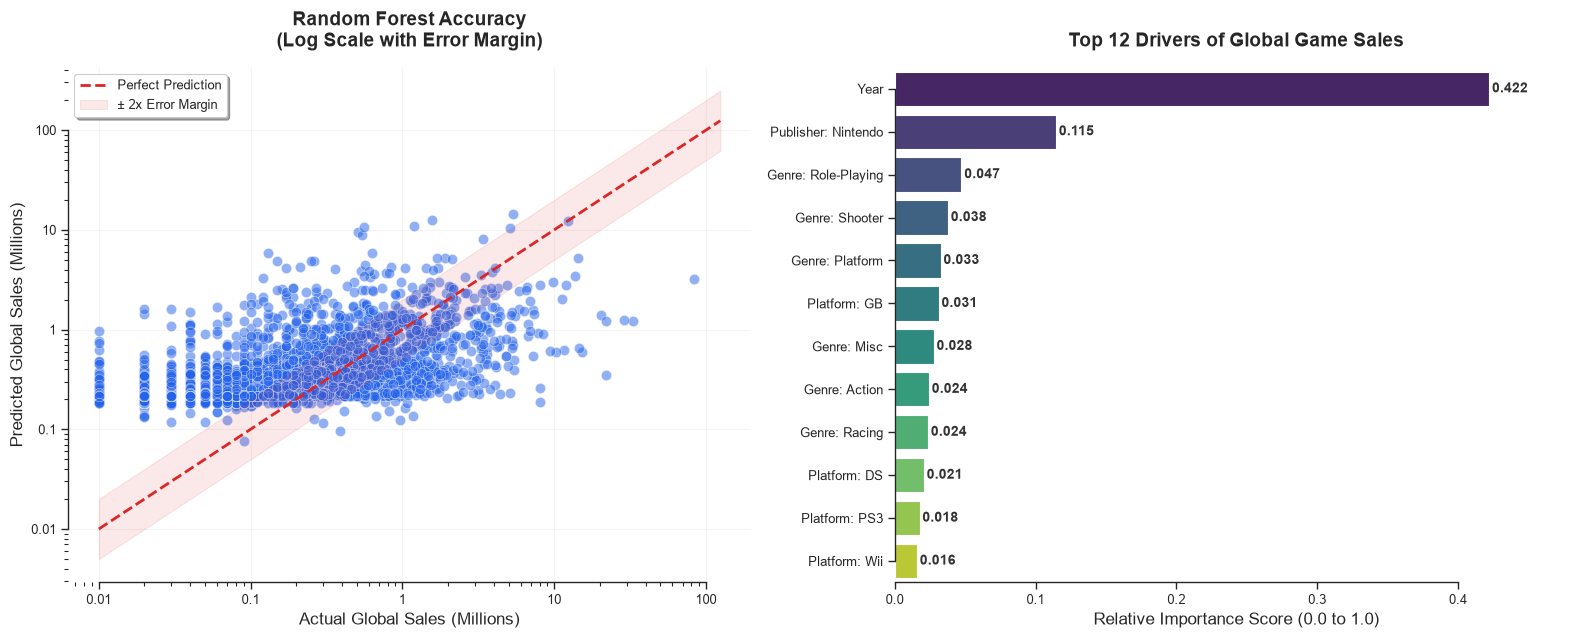

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

sns.set_theme(style="ticks", context="paper", font_scale=1.1)
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# PLOT 1: Log-Scale Scatter with Error Band
ax1 = axes[0]

sns.scatterplot(
    x=y_test, y=y_pred_rf,
    alpha=0.5, color="#2563EB", # Modern Tailwind Blue
    s=55, edgecolor="white", linewidth=0.5,
    ax=ax1
)

min_val = 0.01
max_val = max(y_test.max(), y_pred_rf.max()) * 1.5

# Perfect Prediction Line
ax1.plot([min_val, max_val], [min_val, max_val], color='#DC2626', linestyle='--', linewidth=2, label="Perfect Prediction")

ax1.fill_between([min_val, max_val],
                 [min_val * 0.5, max_val * 0.5],
                 [min_val * 2, max_val * 2],
                 color='#DC2626', alpha=0.1, label="± 2x Error Margin")

ax1.set_xscale('log')
ax1.set_yscale('log')

formatter = ticker.FuncFormatter(lambda y, _: '{:g}'.format(y))
ax1.xaxis.set_major_formatter(formatter)
ax1.yaxis.set_major_formatter(formatter)

ax1.set_title('Random Forest Accuracy\n(Log Scale with Error Margin)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Actual Global Sales (Millions)', fontsize=12, fontweight='400')
ax1.set_ylabel('Predicted Global Sales (Millions)', fontsize=12, fontweight='400')
ax1.legend(loc="upper left", frameon=True, shadow=True)
ax1.grid(True, which="major", ls="-", alpha=0.2)

# PLOT 2: Feature Importance with Data Labels
ax2 = axes[1]

# Extract and clean feature data
importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df['Feature'] = feature_df['Feature'].str.replace('_', ': ')
top_features = feature_df.sort_values(by='Importance', ascending=False).head(12)

bars = sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features,
    hue='Feature',
    palette="viridis",
    legend=False,
    ax=ax2
)

for p in bars.patches:
    width = p.get_width()
    ax2.text(width + 0.002,
             p.get_y() + p.get_height() / 2,
             f'{width:.3f}',
             ha='left', va='center',
             fontsize=10, color='#333333', fontweight='bold')

ax2.set_xlim(0, top_features['Importance'].max() * 1.15)

ax2.set_title('Top 12 Drivers of Global Game Sales', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Relative Importance Score (0.0 to 1.0)', fontsize=12, fontweight='500')
ax2.set_ylabel('')

sns.despine(trim=True)
plt.tight_layout()
plt.show()

## 💡 9. Final Dashboard Conclusions

By mapping our results visually, the model's behavior becomes immediately clear:

1. **The Blockbuster Ceiling:** The log-scale scatter plot proves that while the Random Forest accurately predicts standard games (clustering beautifully inside the red ± 2x error margin), it hits a hard mathematical ceiling. It completely fails to extrapolate the sales of massive outliers, severely underpredicting 1M+ hits.
2. **Nintendo & Timing Dominate:** The feature importance chart reveals that the release `Year` and being published by `Nintendo` are the strongest categorical signals for global sales volume, vastly outweighing specific genres or platforms in predictive weight.